In [1]:
import os
import sys
import argparse
import torch
import torch.nn as nn

from tqdm import tqdm
from pathlib import Path
from typing import List, Optional
from torch.utils.data import DataLoader
from src.models.our_method.older_surrogate import MultiHeadOlderSurrogate
from src.models.our_method.swin_cafm import SwinCAFM
from src.datasets.mos2_sef import MOS2SEFDataset, Formulation as F
from src.util.logger import ExperimentLogger
from src.util.loss import ImageInpaintingL1Loss
from src.util.config import (
    TrainConfig,
    ModelConfig,
    LOSS_FUNCTIONS,
    OPTIMIZERS,
    MODELS,
)

TRAIN_CONFIG_FP = os.path.abspath("configs/train.yaml")


def setup_logger(
    train_config: TrainConfig, model_config: Optional[ModelConfig]
) -> ExperimentLogger:
    logger = ExperimentLogger(
        train_config_dict=train_config.to_dict(),
        model_config_dict=model_config.to_dict() if model_config != None else None,
        root=train_config.log_root,
        exp_name=train_config.exp_name,
        log_interval=train_config.log_interval,
    )
    logger.add_result_columns(train_config.result_columns)
    return logger


def create_model(config: TrainConfig) -> nn.Module:
    model_fn = MODELS[config.model_name]["fn"]
    model_weights = MODELS[config.model_name]["weights"]
    if model_weights:
        model = model_fn(weights=model_weights)
    elif config.model_name == "hiera":
        model = model_fn
        model.freeze()
    else:
        model = model_fn()
    assert isinstance(model, nn.Module)
    return model.cuda(config.device).float()


def create_surrogate(config: TrainConfig) -> nn.Module:
    """
    Create an OLDER surrogate module.
    """
    surrogate_fn = MODELS[config.surrogate_name]["fn"]
    surrogate_weights = MODELS[config.surrogate_name]["weights"]
    surrogate: MultiHeadOlderSurrogate = surrogate_fn()
    if surrogate_weights:
        surrogate.load_state_dict(torch.load(surrogate_weights))
    assert isinstance(surrogate, MultiHeadOlderSurrogate)
    return surrogate.cuda(config.device).float()


def create_dataloader(config: TrainConfig, split: str) -> DataLoader:
    img_size = int(config.image_size)
    dataset = MOS2SEFDataset(
        split=split,
        side_length=int(config.crop_size),
        formulation=F.get_formulation_from_str(config.formulation),
        steps_per_epoch=(
            config.steps_per_epoch if split == "train" else config.val_steps_per_epoch
        ),
        device=config.device,
        original_image_size=(img_size, img_size),
        masking_ratio=int(config.masking_ratio),
    )
    return DataLoader(
        dataset,
        batch_size=config.train_batch_size,
        shuffle=False,
        num_workers=config.num_workers,
    )

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/pytorch_lightning/plugins/training_type/ddp.py:68: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import DistributedOptimizer


In [2]:
# load training config
config = TrainConfig(TRAIN_CONFIG_FP)
model_config: Optional[ModelConfig] = None

# optional: parse model config
if config.model_config_file != None:
    model_config_abs_path = os.path.join(
        Path(TRAIN_CONFIG_FP).parent.__str__(), config.model_config_file
    )
    assert os.path.isfile(
        model_config_abs_path
    ), f"Bad path to model config: {model_config_abs_path}"
    model_config = ModelConfig(model_config_abs_path)

# -------------------- training config args --------------------
config.surgate_weights = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/e. surrogate standalone train-runs/2025-02-08_12-36-35_older_surrogate_mh-ViT-l[-2]+layernorm/older_surrogate_mh-ViT-l[-2]+layernorm_latest_older_surrogate.pth"

In [3]:
model = create_model(config)
surrogate: MultiHeadOlderSurrogate = create_surrogate(config)

train_dataloader = create_dataloader(config, "train")
val_dataloader = create_dataloader(config, "val")

# define loss function and optimizer
train_loss: torch.nn.Module = LOSS_FUNCTIONS[config.train_loss]()
val_loss: torch.nn.Module = LOSS_FUNCTIONS[config.val_loss]()

# use to save model checkpoints
best_val_loss = sys.maxsize

num_epochs = config.epochs
device = config.device

# load weights from checkpoint
if config.weights != None:
    # load enitre model object:
    model = torch.load(config.weights).float().cuda()

optimizer: torch.optim.Optimizer = OPTIMIZERS[config.optimizer](
    model.parameters(), lr=float(config.learning_rate)
)

model.cuda(device)
model.float()

# surrogate model is used purely as an evaluator
surrogate.eval();

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


KeyboardInterrupt: 

In [ ]:
from src.datasets.mos2_sef_surrogate import MOS2SefOLDERSurrogate

mos2_dataset = MOS2SefOLDERSurrogate(steps_per_epoch=2000)
dataloader = DataLoader(
        mos2_dataset,
        batch_size=config.train_batch_size,
        shuffle=False,
        num_workers=config.num_workers,
)


In [ ]:
import pprint

items = {}
for batch in tqdm(dataloader, total=len(dataloader)):
    char: dict = batch["y_char"]
    for k in char:
        val = char[k].detach().cpu().numpy()[0]
        if not k in items: items[k] = [val]
        else: items[k].append(val)

pprint.pprint(items)

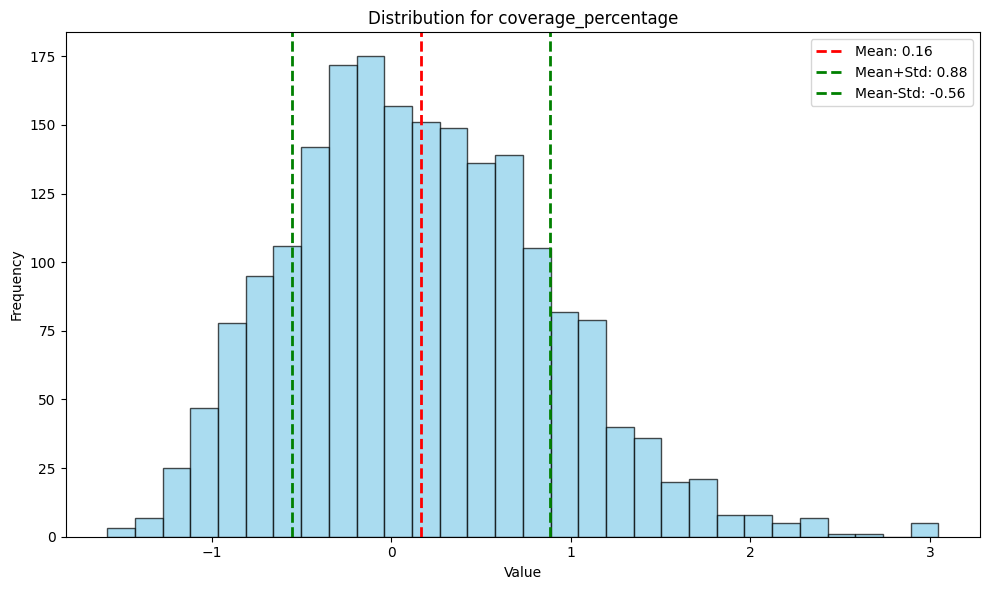

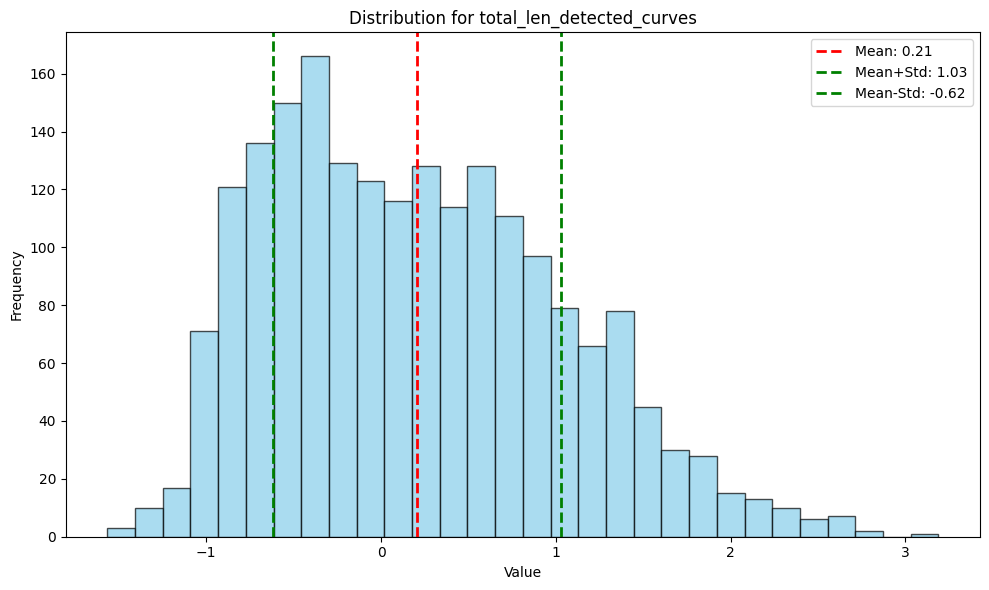

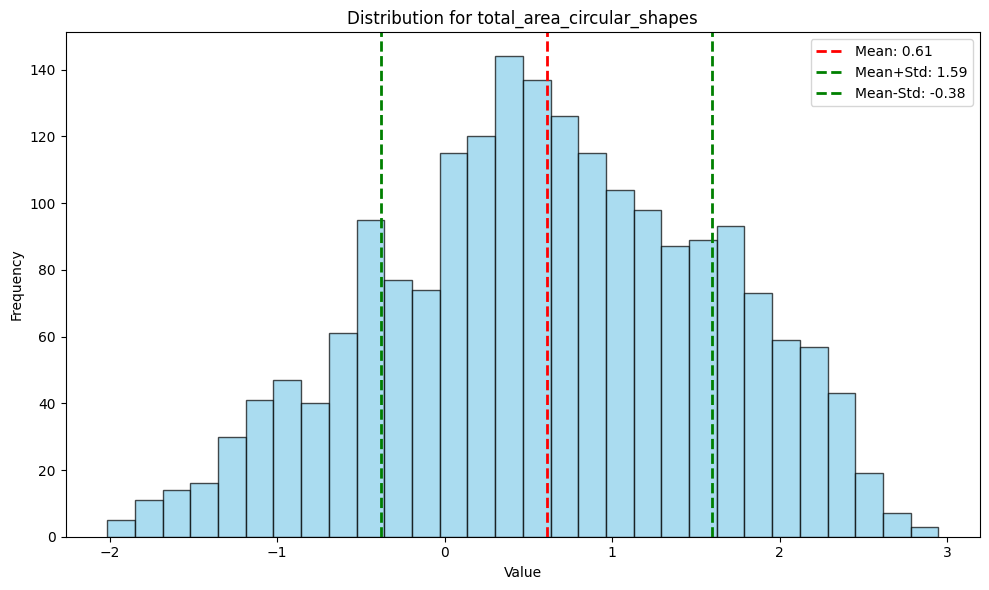

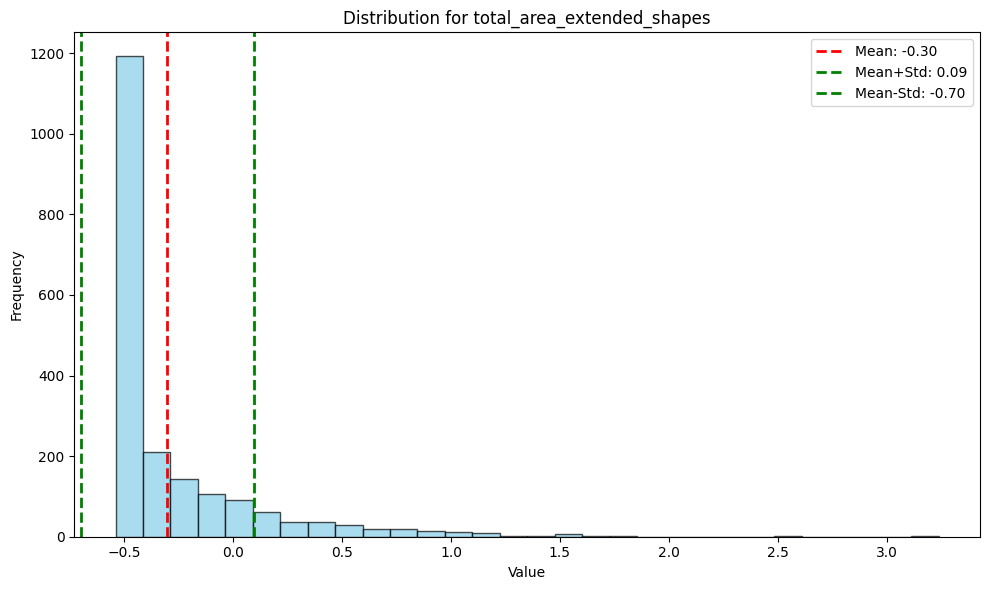

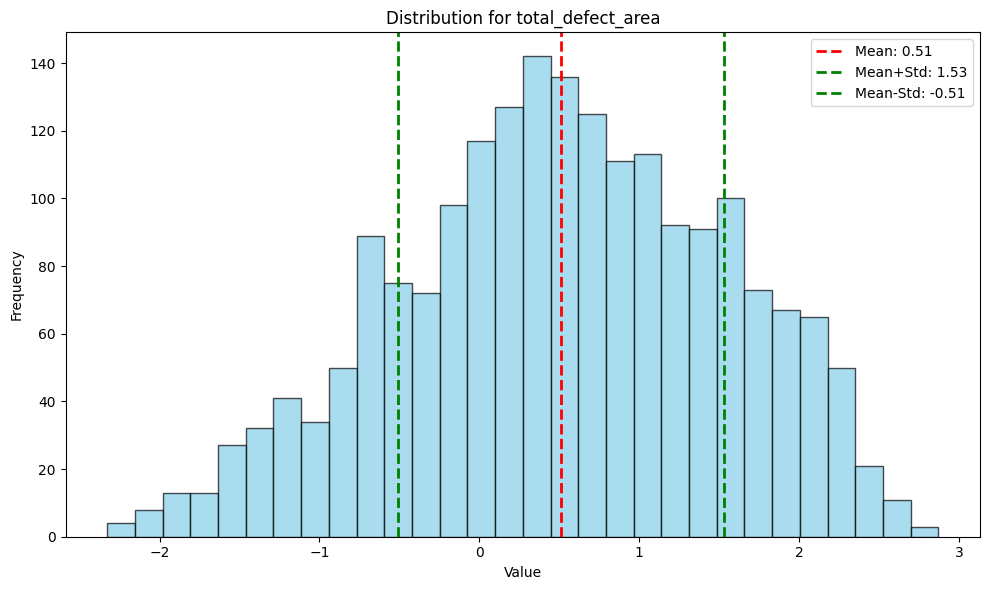

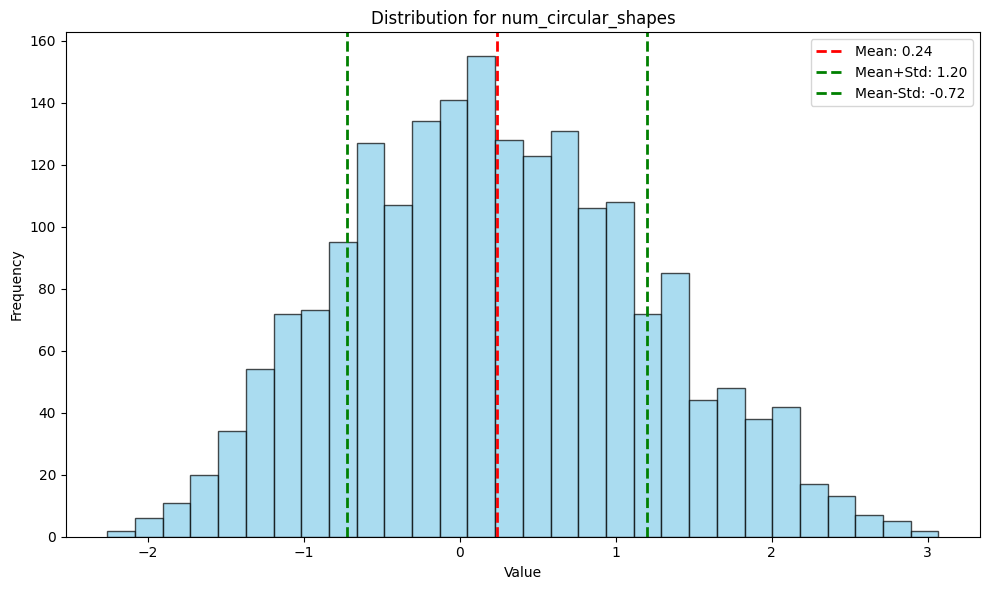

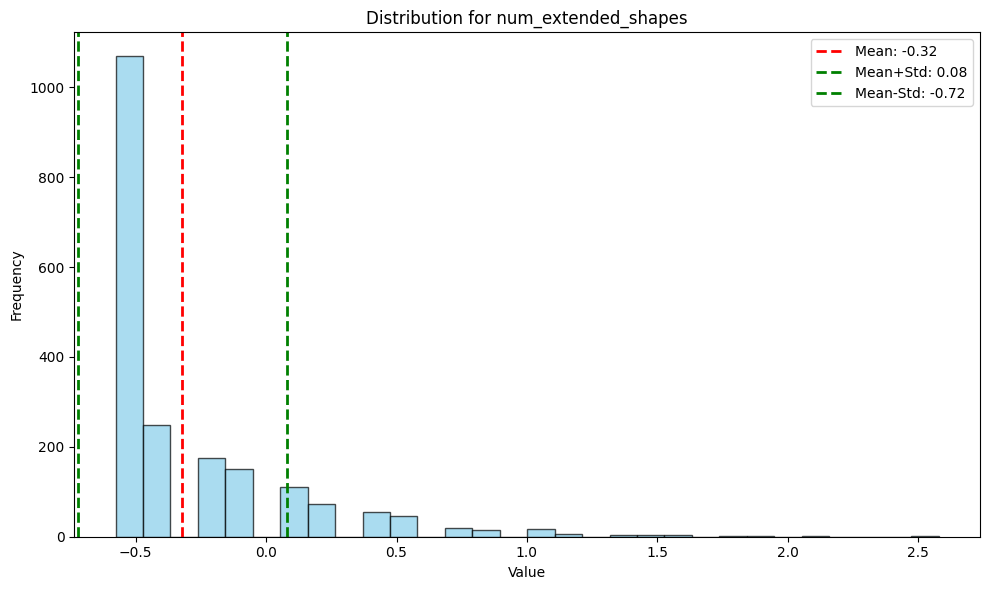

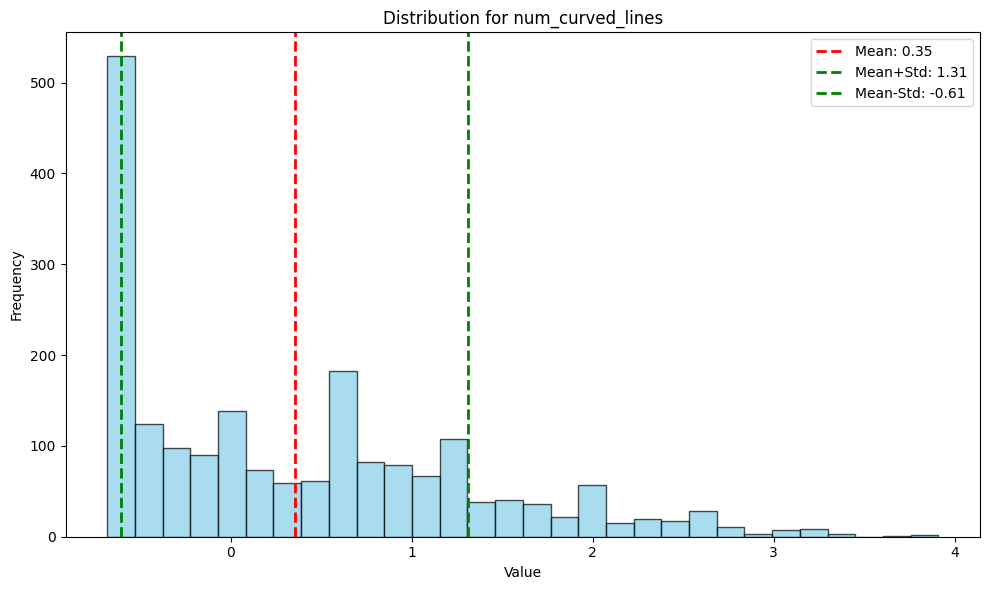

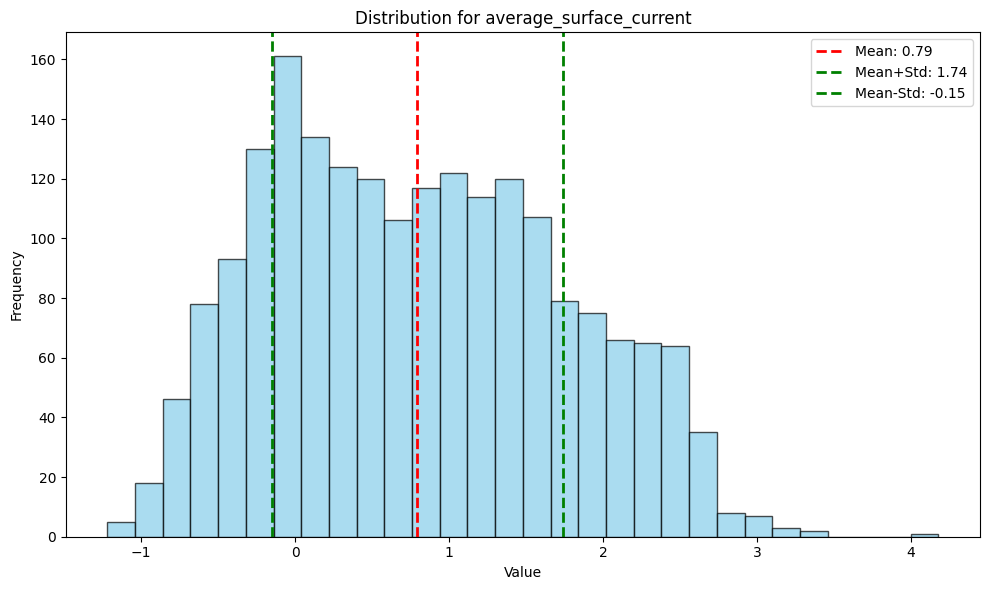

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming items is your dictionary with str: List[float] pairs
# For example, items might look like: {"A": [1.2, 1.5, 1.1, ...], "B": [2.0, 2.3, 1.9, ...]}

for key, values in items.items():
    # Convert list to NumPy array for easy computation.
    values_array = np.array(values)
    
    # Calculate statistics.
    mean_val = np.mean(values_array)
    std_val = np.std(values_array)

    # Create a figure for the current key.
    plt.figure(figsize=(10, 6))
    
    # Plot histogram.
    plt.hist(values_array, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Plot the mean.
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    
    # Plot mean + std and mean - std.
    plt.axvline(mean_val + std_val, color='green', linestyle='dashed', linewidth=2,
                label=f'Mean+Std: {(mean_val + std_val):.2f}')
    plt.axvline(mean_val - std_val, color='green', linestyle='dashed', linewidth=2,
                label=f'Mean-Std: {(mean_val - std_val):.2f}')
    
    # Add titles and labels.
    plt.title(f'Distribution for {key}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()  # Improves spacing.
    plt.show()


In [ ]:
from src.datasets.mos2_sef_surrogate import MOS2SefOLDERSurrogate

mos2_dataset = MOS2SefOLDERSurrogate(split="val", steps_per_epoch=2000)
dataloader = DataLoader(
        mos2_dataset,
        batch_size=config.train_batch_size,
        shuffle=False,
        num_workers=config.num_workers,
)

In [ ]:
items = {}
for batch in tqdm(dataloader, total=len(dataloader)):
    char: dict = batch["y_char"]
    for k in char:
        val = char[k].detach().cpu().numpy()[0]
        if not k in items: items[k] = [val]
        else: items[k].append(val)

100%|██████████| 2000/2000 [04:49<00:00,  6.90it/s]


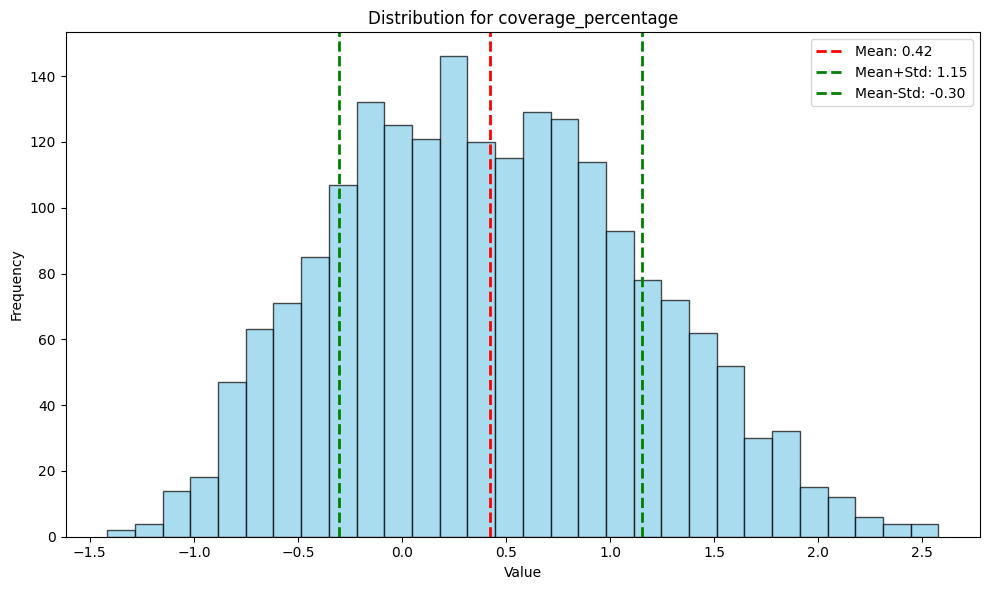

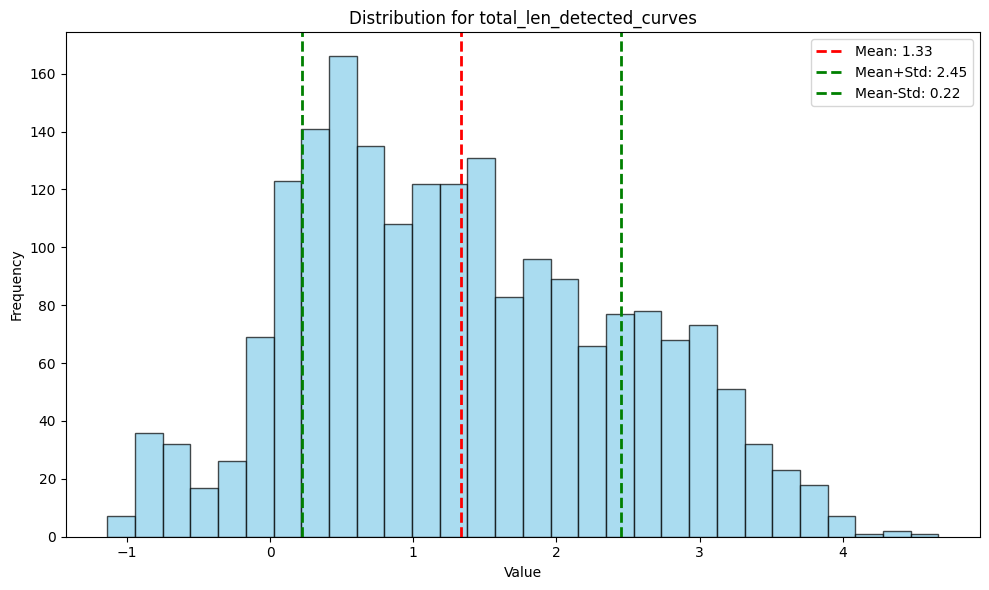

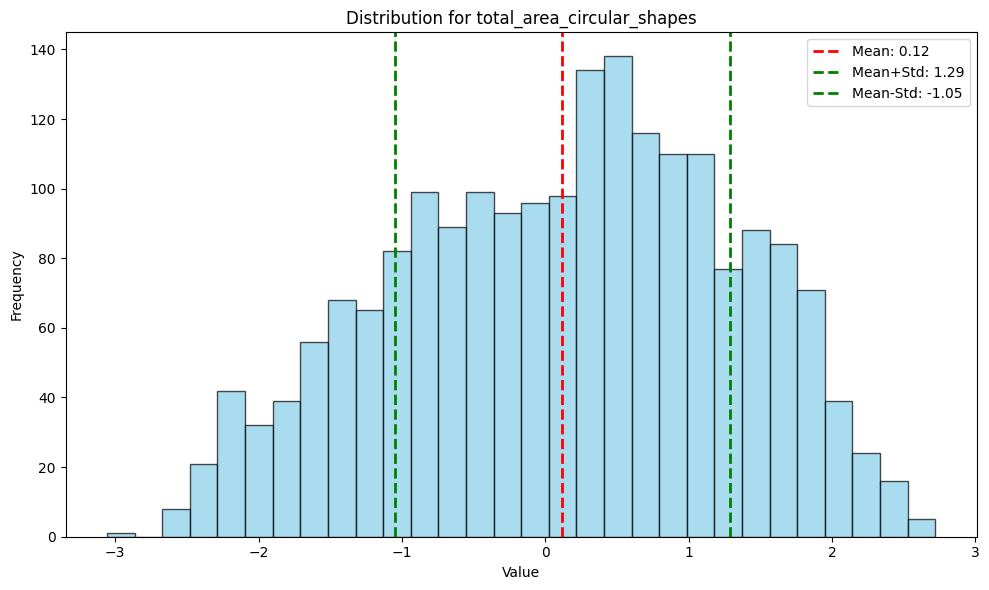

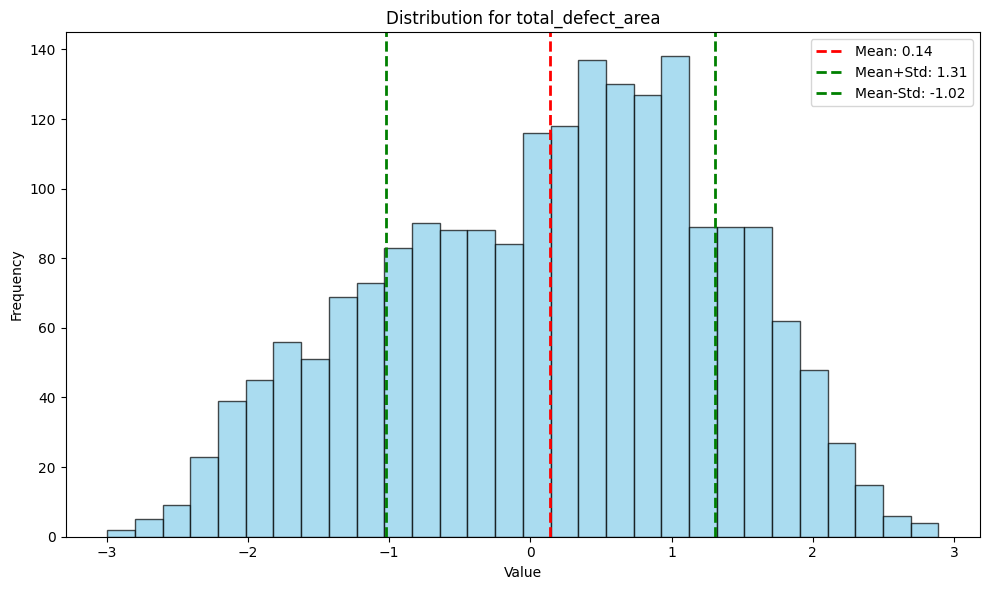

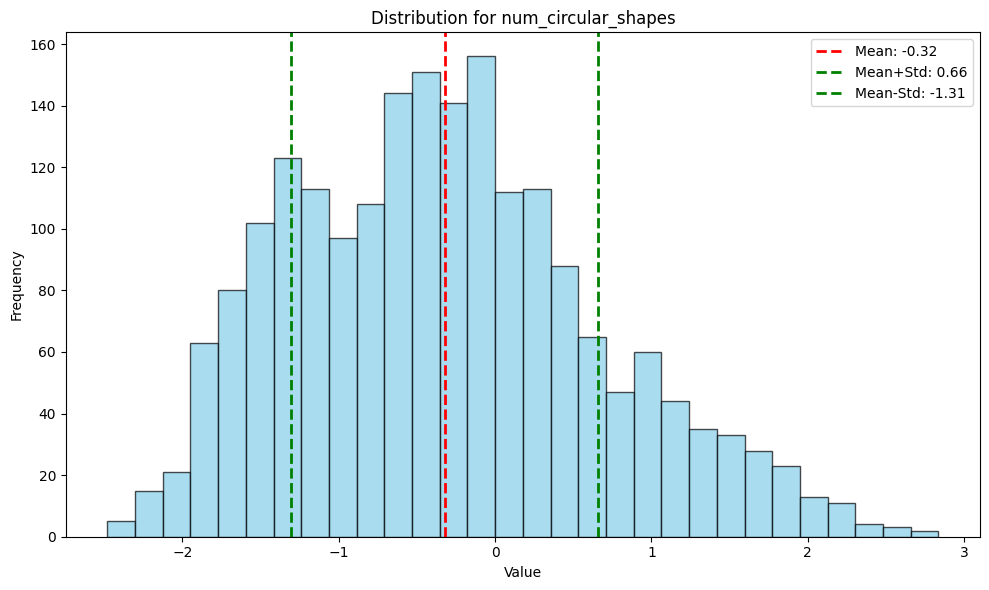

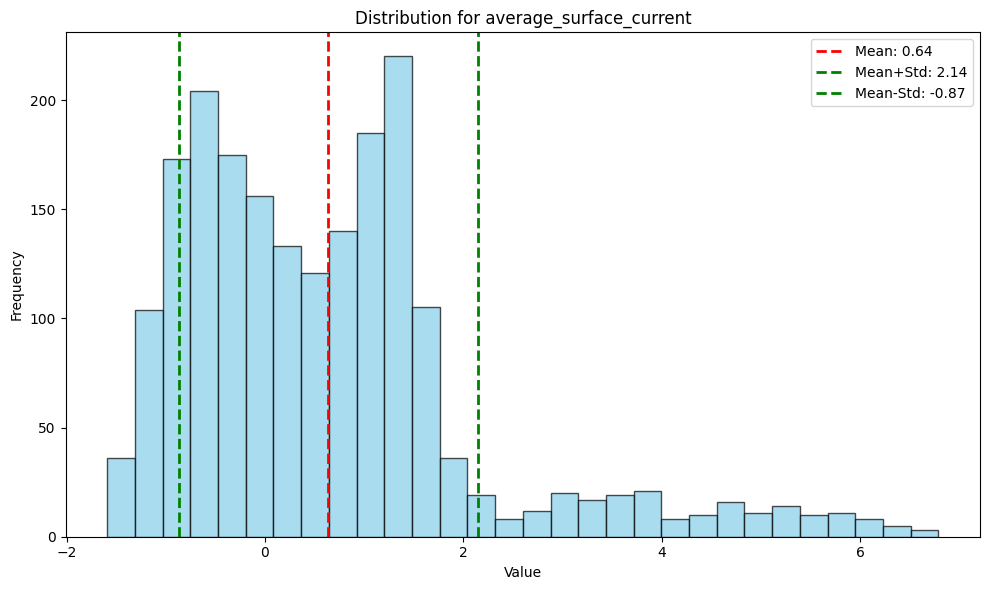

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming items is your dictionary with str: List[float] pairs
# For example, items might look like: {"A": [1.2, 1.5, 1.1, ...], "B": [2.0, 2.3, 1.9, ...]}

for key, values in items.items():
    # Convert list to NumPy array for easy computation.
    values_array = np.array(values)
    
    # Calculate statistics.
    mean_val = np.mean(values_array)
    std_val = np.std(values_array)

    # Create a figure for the current key.
    plt.figure(figsize=(10, 6))
    
    # Plot histogram.
    plt.hist(values_array, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Plot the mean.
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    
    # Plot mean + std and mean - std.
    plt.axvline(mean_val + std_val, color='green', linestyle='dashed', linewidth=2,
                label=f'Mean+Std: {(mean_val + std_val):.2f}')
    plt.axvline(mean_val - std_val, color='green', linestyle='dashed', linewidth=2,
                label=f'Mean-Std: {(mean_val - std_val):.2f}')
    
    # Add titles and labels.
    plt.title(f'Distribution for {key}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()  # Improves spacing.
    plt.show()


In [ ]:
num_epochs=1
older_losses = []

# ---------- training loop ----------
for epoch in range(num_epochs):

    model.train()

    for i, batch in enumerate(
        tqdm(train_dataloader, desc=f"Training: Epoch {epoch+1}/{num_epochs}")
    ):
        # topo-map:    X
        X: torch.Tensor = batch["X"].cuda(device)

        # current-map: y
        y: torch.Tensor = batch["y"].cuda(device)

        # ---- remove masked pixels ----
        mask: torch.Tensor = batch["mask"].cuda(device)
        y_sparse = (y * mask).float()

        # zero gradients
        optimizer.zero_grad()

        # ---- forward: p(y | y_sparse) ----
        outputs = model(y_sparse)

        # final model prediction with given unmasked pixels
        y_hat = ImageInpaintingL1Loss.get_final_prediction(
            predicted_image=outputs, target_image=y, mask=mask
        )

        # NOTE: standard loss (e.g., L1)
        char_1 = surrogate(y); char_2 = surrogate(y_hat)
        
        # NOTE: raw model outputs
        # --- Loss: L1 ---
        # loss: torch.Tensor = torch.nn.functional.l1_loss(y, outputs)
        # --- Loss: OLDER ---
        loss: torch.Tensor = train_loss(char_1, char_2)
        # --- Loss: OLDER + L1 ---
        # loss: torch.Tensor = train_loss(char_1, char_2) + torch.nn.functional.l1_loss(y, outputs)
        
        # NOTE: final pred
        # --- Loss: L1 ---
        # loss: torch.Tensor = torch.nn.functional.l1_loss(y, y_hat)
        # --- Loss: OLDER ---
        # loss: torch.Tensor = train_loss(char_1, char_2)
        # --- Loss: OLDER + L1 ---
        # loss: torch.Tensor = train_loss(char_1, char_2) + torch.nn.f
        # unctional.l1_loss(y, outputs)
        
        loss.backward()
        older_losses.append(loss.item())
        optimizer.step()

Training: Epoch 1/1:   2%|▏         | 17/1024 [00:04<04:23,  3.82it/s]


KeyboardInterrupt: 

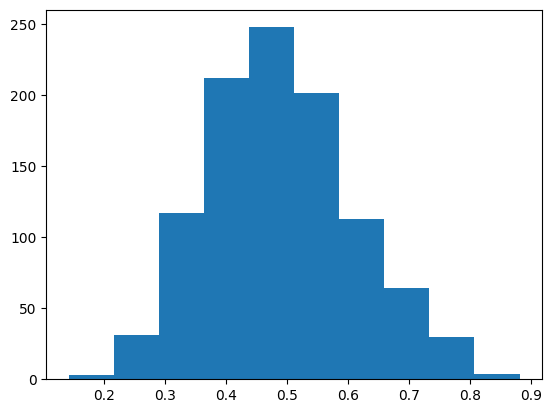

In [ ]:
import matplotlib.pyplot as plt
plt.hist(older_losses);

In [ ]:
# validation
model.eval()
val_running_loss = 0.0
num_val_steps = 1

with torch.no_grad():
    for i, batch in enumerate(
        tqdm(val_dataloader, desc=f"Validation: Epoch {epoch+1}/{num_epochs}")
    ):
        # topo-map:    X
        X: torch.Tensor = batch["X"].cuda(device)

        # current-map: y
        y: torch.Tensor = batch["y"].cuda(device)

        # ---- remove masked pixels ----
        mask: torch.Tensor = batch["mask"].cuda(device)
        y_sparse = (y * mask).float()

        # ---- forward: p(y | y_sparse) ----
        outputs = model(y_sparse)

        # final model prediction with given unmasked pixels
        y_hat = ImageInpaintingL1Loss.get_final_prediction(
            predicted_image=outputs, target_image=y, mask=mask
        )

        # NOTE: standard loss (e.g., L1)
        # loss: torch.Tensor = train_loss(outputs, y))
        char_1 = surrogate(y); char_2 = surrogate(y_hat)
        
        # Loss: L1
        loss: torch.Tensor = torch.nn.functional.l1_loss(y, outputs)
        # Loss: OLDER
        # loss: torch.Tensor = train_loss(char_1, char_2)
        # Loss: OLDER + L1
        # loss: torch.Tensor = train_loss(char_1, char_2) + torch.nn.functional.l1_loss(y, outputs)

        val_running_loss += loss.item() * y_sparse.size(0)

    # optional: log best/recent model weights
    avg_val_loss = val_running_loss / num_val_steps
